# Volatility Modeling

In this stage, we model conditional volatility using ARCH and GARCH models.

Objectives:
1. Model time-varying volatility
2. Capture volatility clustering
3. Forecast future volatility
4. Compare volatility dynamics across assets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sp500 = pd.read_csv("../data/SP500_processed.csv", index_col="Date", parse_dates=True)
btc = pd.read_csv("../data/BTC_processed.csv", index_col="Date", parse_dates=True)

In [3]:
!pip install arch


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from arch import arch_model

In [5]:
garch_sp500 = arch_model(
    sp500["log_return"] * 100,
    vol="Garch",
    p=1,
    q=1
)

result_sp500 = garch_sp500.fit()

print(result_sp500.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 35096909917.48849
Iteration:      2,   Func. Count:     15,   Neg. LLF: 1745377528.0832667
Iteration:      3,   Func. Count:     22,   Neg. LLF: 5079.150787775072
Iteration:      4,   Func. Count:     28,   Neg. LLF: 4728.679679916608
Iteration:      5,   Func. Count:     35,   Neg. LLF: 6759.329292087022
Iteration:      6,   Func. Count:     41,   Neg. LLF: 3872.839006923531
Iteration:      7,   Func. Count:     46,   Neg. LLF: 3872.7301442130283
Iteration:      8,   Func. Count:     51,   Neg. LLF: 3872.7177315685813
Iteration:      9,   Func. Count:     56,   Neg. LLF: 3872.7176854214986
Iteration:     10,   Func. Count:     61,   Neg. LLF: 3872.7176839206295
Iteration:     11,   Func. Count:     65,   Neg. LLF: 3872.7176839207805
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3872.7176839206295
            Iterations: 11
            Function evaluations: 65
            Gradient evaluati

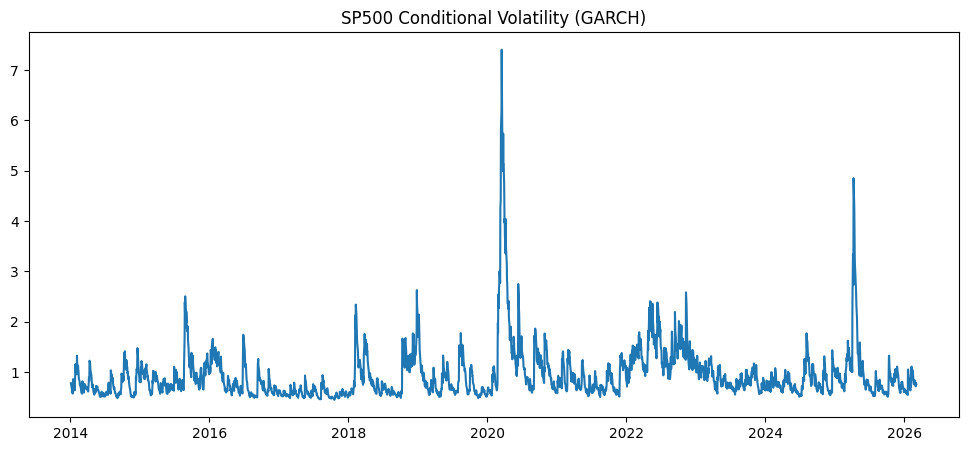

In [6]:
plt.figure(figsize=(12,5))

plt.plot(result_sp500.conditional_volatility)
plt.title("SP500 Conditional Volatility (GARCH)")
plt.show()

### Conditional Volatility

The GARCH model captures time-varying volatility and volatility clustering.

Periods of market stress correspond to spikes in conditional volatility.

In [7]:
garch_btc = arch_model(
    btc["log_return"] * 100,
    vol="Garch",
    p=1,
    q=1
)

result_btc = garch_btc.fit()

print(result_btc.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 29355.288562225374
Iteration:      2,   Func. Count:     17,   Neg. LLF: 28724.507555180004
Iteration:      3,   Func. Count:     24,   Neg. LLF: 41649.64398941818
Iteration:      4,   Func. Count:     32,   Neg. LLF: 12777.676468181446
Iteration:      5,   Func. Count:     39,   Neg. LLF: 10866.322917596095
Iteration:      6,   Func. Count:     45,   Neg. LLF: 10851.644340351035
Iteration:      7,   Func. Count:     50,   Neg. LLF: 10851.642415183931
Iteration:      8,   Func. Count:     55,   Neg. LLF: 10851.641225556521
Iteration:      9,   Func. Count:     60,   Neg. LLF: 10851.641221008194
Iteration:     10,   Func. Count:     64,   Neg. LLF: 10851.641221007703
Optimization terminated successfully    (Exit mode 0)
            Current function value: 10851.641221008194
            Iterations: 10
            Function evaluations: 64
            Gradient evaluations: 10
                     Constant Mean - GARCH Model Results     

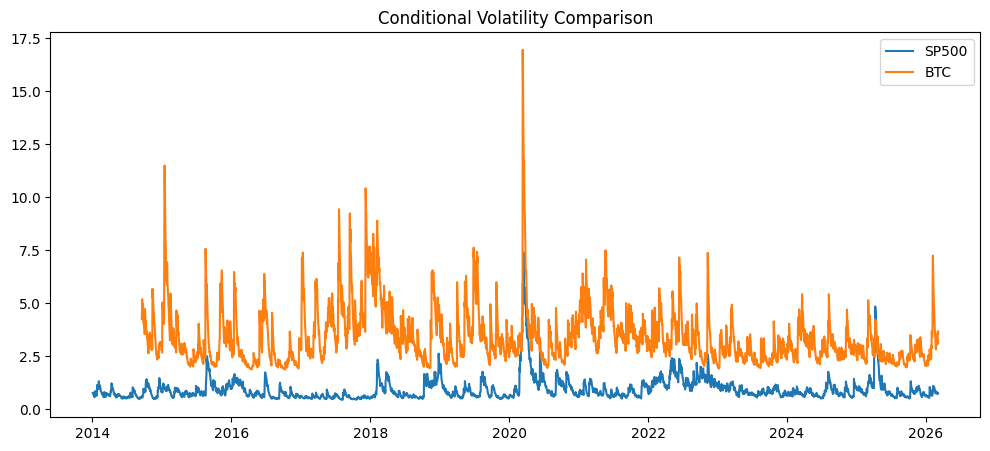

In [8]:
plt.figure(figsize=(12,5))

plt.plot(result_sp500.conditional_volatility, label="SP500")
plt.plot(result_btc.conditional_volatility, label="BTC")

plt.legend()
plt.title("Conditional Volatility Comparison")
plt.show()

In [9]:
forecast = result_sp500.forecast(horizon=5)

print(forecast.variance.tail())

                 h.1       h.2       h.3      h.4       h.5
Date                                                       
2026-03-06  0.850377  0.861803  0.872836  0.88349  0.893778


In [10]:
split_index = int(len(sp500) * 0.8)

train = sp500["log_return"][:split_index] * 100
test = sp500["log_return"][split_index:] * 100

In [11]:
model = arch_model(
    train,
    vol="Garch",
    p=1,
    q=1
)

result = model.fit(disp="off")

print(result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3099.66
Distribution:                  Normal   AIC:                           6207.32
Method:            Maximum Likelihood   BIC:                           6230.54
                                        No. Observations:                 2448
Date:                Thu, May 14 2026   Df Residuals:                     2447
Time:                        15:05:56   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0832  1.458e-02      5.709  1.135e-08 [5.466e-0

In [12]:
forecast = result.forecast(
    horizon=len(test)
)

forecast_variance = forecast.variance.values[-1]

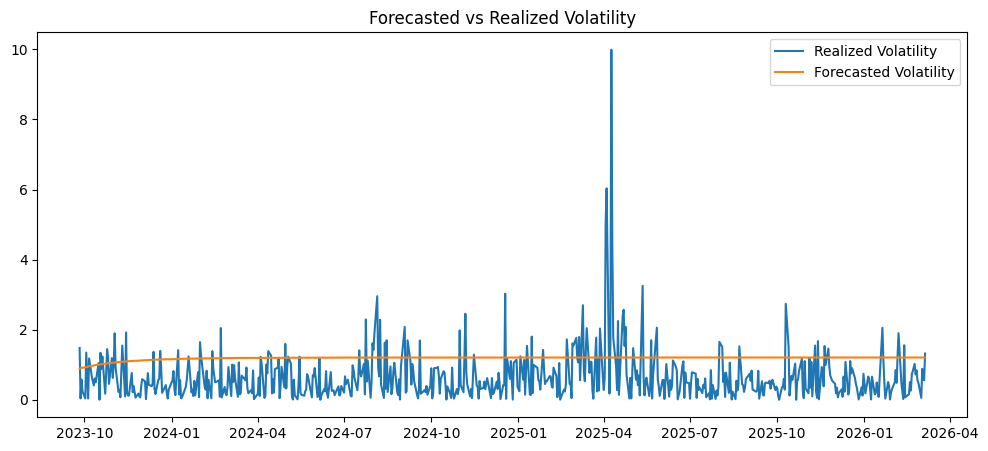

In [13]:
plt.figure(figsize=(12,5))

plt.plot(test.index, np.abs(test), label="Realized Volatility")

plt.plot(
    test.index,
    np.sqrt(forecast_variance),
    label="Forecasted Volatility"
)

plt.legend()

plt.title("Forecasted vs Realized Volatility")

plt.show()

## GARCH Forecast Interpretation

The GARCH model captures broad volatility dynamics and periods of elevated market uncertainty.

Although exact volatility spikes are difficult to predict, the model successfully captures volatility persistence and clustering behavior.